# Part 01 Trigrams

The chain rule of probability for a trigram results in:

$$
P(X_1 \cdots X_3) = P(X_1) \times P(X_2 \mid X_1) \times P(X_3 \mid X_{1:2})
$$

Write out the equation for trigram probability estimation by applying this (modifying Eq. 3.11, p. 32 in the book, slide x in PDF).

Next, write out all the non-zero trigram probabilities for the "I am Sam corpus":

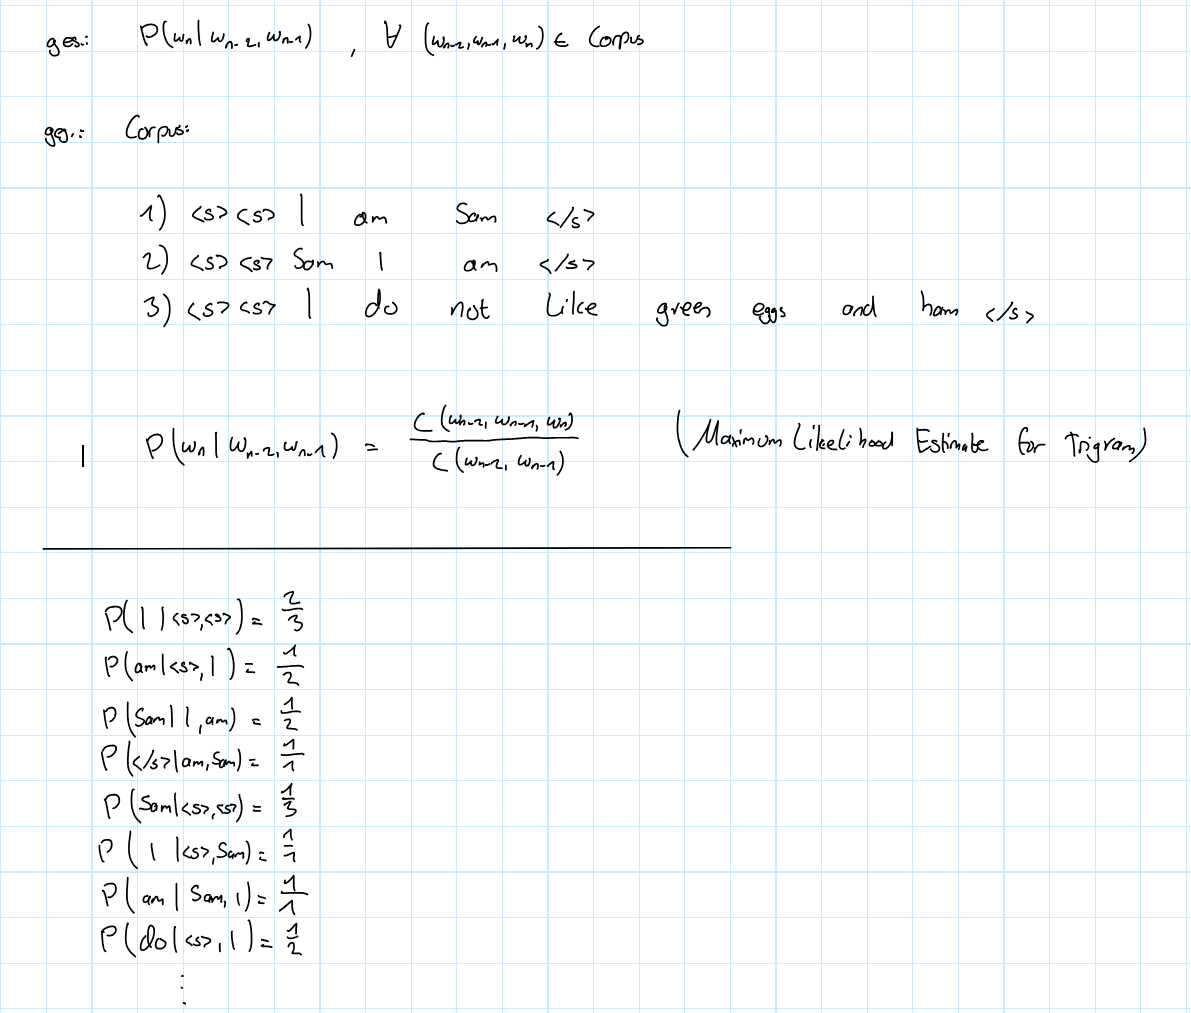

# Part 02 Probability of the sentence "i want chinese food"

Calculate the probability of the sentence "i want chinese food" (i.e., $P(\langle s \rangle \text{ i want chinese food } \langle /s \rangle)$). 

Give two probabilities:
1. One using the **Unsmoothed Bigram Probabilities** (Fig. 3.2).
2. Another using the **Add-One (Laplace) Smoothed Bigram Probabilities** (Fig. 3.7).

---

### Reference Data

#### 1. Unsmoothed Bigram Probabilities (Fig. 3.2)
*Columns represent the current word ($w_n$), and rows represent the preceding history word ($w_{n-1}$):*

| $w_{n-1}$ \ $w_n$ | i | want | to | eat | chinese | food | lunch | spend |
|---|---|---|---|---|---|---|---|---|
| **i** | 0.002 | 0.33 | 0.0 | 0.0036 | 0.0 | 0.00 | 0.0 | 0.00079 |
| **want** | 0.0022 | 0.0 | 0.66 | 0.0011 | 0.0065 | 0.0065 | 0.0054 | 0.0011 |
| **to** | 0.00083 | 0.0 | 0.0017 | 0.28 | 0.00083 | 0.0 | 0.0025 | 0.087 |
| **eat** | 0.0 | 0.0 | 0.0027 | 0.0 | 0.021 | 0.0027 | 0.056 | 0.0 |
| **chinese** | 0.0063 | 0.0 | 0.0 | 0.0 | 0.0 | 0.52 | 0.0063 | 0.0 |
| **food** | 0.014 | 0.0 | 0.014 | 0.0 | 0.00092 | 0.0037 | 0.0 | 0.0 |

*Additional Unsmoothed Probabilities:*
* $P(\text{i} \mid \langle s \rangle) = 0.25$
* $P(\langle /s \rangle \mid \text{food}) = 0.68$

---

#### 2. Add-One Smoothed Bigram Probabilities (Fig. 3.7 / Slide 21)
*Columns represent the current word ($w_n$), and rows represent the preceding history word ($w_{n-1}$):*

| $w_{n-1}$ \ $w_n$ | i | want | to | eat | chinese | food | lunch | spend |
|---|---|---|---|---|---|---|---|---|
| **i** | 0.0015 | 0.21 | 0.00025 | 0.0025 | 0.00025 | 0.00025 | 0.00025 | 0.00075 |
| **want** | 0.0013 | 0.00042 | 0.26 | 0.00084 | 0.0029 | 0.0029 | 0.0025 | 0.00084 |
| **to** | 0.00078 | 0.00026 | 0.0013 | 0.18 | 0.00078 | 0.00026 | 0.0018 | 0.055 |
| **eat** | 0.00046 | 0.00046 | 0.0014 | 0.00046 | 0.0078 | 0.0014 | 0.02 | 0.00046 |
| **chinese** | 0.0012 | 0.00062 | 0.00062 | 0.00062 | 0.00062 | 0.052 | 0.0012 | 0.00062 |
| **food** | 0.0063 | 0.00039 | 0.0063 | 0.00039 | 0.00079 | 0.002 | 0.00039 | 0.00039 |

*Additional Smoothed Probabilities:*
* $P(\text{i} \mid \langle s \rangle) = 0.19$
* $P(\langle /s \rangle \mid \text{food}) = 0.40$

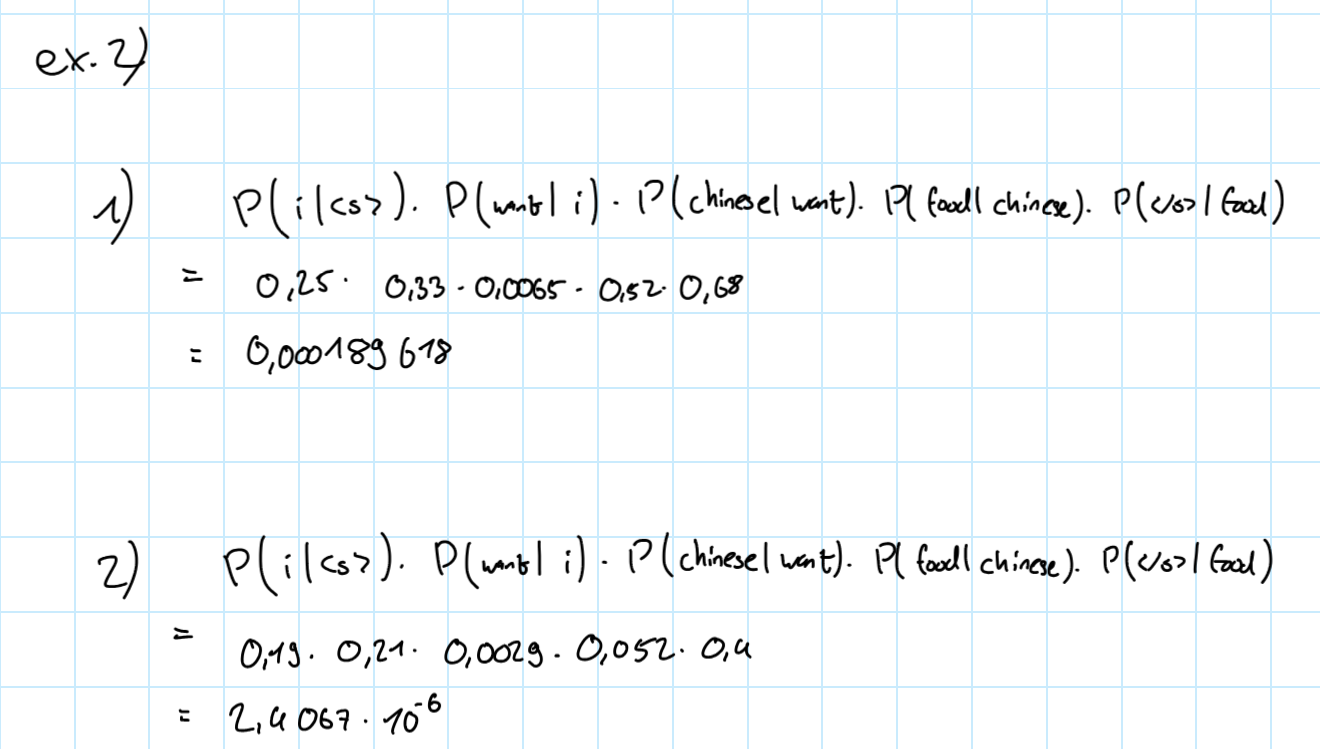

# Part 03 Comparison of Probabilities

Which of the two probabilities you computed in the previous exercise is higher, unsmoothed or smoothed? Explain why.

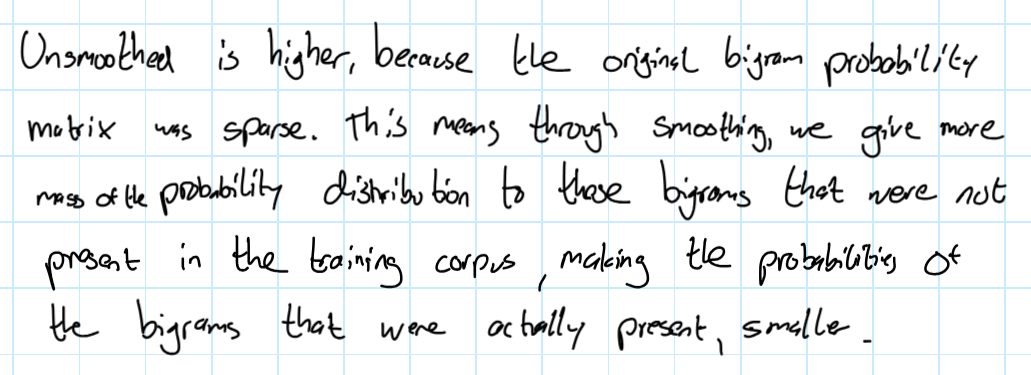

### Part 04
```markdown
# Part 04 Bigrams of Corpus

We are given the following corpus, modified from the one in the chapter:

```text
<s> I am Sam </s>
<s> Sam I am </s>
<s> I am Sam </s>
<s> I do not like green eggs and Sam </s>
```

Write a Python program with the following requirements:

* The sentences shall be implemented as strings.
* Words in a sentence are separated with space.
* Create a list of the given sentences.
* Include `<s>` and `</s>` in your counts just like any other word.
* Write a function that returns the relationship between the occurrence of a specific bigram and all bigrams (apply a bigram language model).
* Write another function that returns the result with add-one smoothing.
* Apply the function on $P(\text{'Sam'} \mid \text{'am'})$!
```

In [27]:
corpus = [
    "<s> I am Sam </s>",
    "<s> Sam I am </s>",
    "<s> I am Sam </s>",
    "<s> I do not like green eggs and Sam </s>"
]

def unigram_counts(corpus=corpus):
    counts = {}

    for sentence in corpus:
        words = sentence.split(" ")

        for w in words:
            if w in counts:
                counts[w] += 1
            else:
                counts[w] = 1
    
    return counts

def bigram_counts(corpus=corpus):
    counts = {}

    for sentence in corpus:
        words = sentence.split(" ")

        for w1, w2 in zip(words, words[1:]):
            if (w1, w2) in counts:
                counts[(w1, w2)] += 1
            else:
                counts[(w1, w2)] = 1

    return counts 

def bigram_probs(corpus=corpus):
    unigrams = unigram_counts()
    bigrams = bigram_counts()

    probs = {}

    for w1, w2 in bigrams.keys():
        probs[(w1, w2)] = bigrams[(w1, w2)] / unigrams[w1]

    return probs

def get_vocab(corpus=corpus):
    return list(set([word for sentence in corpus for word in sentence.split(" ")]))
    
def bigram_probs_smoothed(corpus=corpus):
    unigrams = unigram_counts()
    bigrams = bigram_counts()
    V = len(get_vocab())

    probs = {}

    for w1, w2 in bigrams.keys():
        probs[(w1, w2)] = (bigrams[(w1, w2)] + 1) / (unigrams[w1] + V)

    return probs

def get_prob(w1, w2, corpus=corpus):
    unigrams = unigram_counts(corpus)
    bigrams = bigram_counts(corpus)
    
    # If the history word w1 was never seen, probability is 0
    if w1 not in unigrams:
        return 0.0
        
    return bigrams.get((w1, w2), 0) / unigrams[w1]

def get_prob_smoothed(w1, w2, corpus=corpus):
    unigrams = unigram_counts(corpus)
    bigrams = bigram_counts(corpus)
    V = len(get_vocab(corpus))
    
    count_w1 = unigrams.get(w1, 0)
    count_w1_w2 = bigrams.get((w1, w2), 0)
    
    # If the history word w1 was never seen, we only divide by the vocab size V
    return (count_w1_w2 + 1) / (count_w1 + V)

print(f"Unsmoothed: {get_prob("am", "Sam")}")
print(f"Smoothed: {bigram_probs_smoothed()[("am", "Sam")]}")

Unsmoothed: 0.6666666666666666
Smoothed: 0.21428571428571427
